In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import scanpy as sc
import os
import re
from itertools import compress
import random
import scipy.sparse
import time
import warnings
import numba
import random
import matplotlib.patches as mpatches
import h5py

sc.set_figure_params(dpi=80)

%config InlineBackend.figure_format='retina'


In [ ]:
plt.rcParams['axes.grid'] = False
fontsize = 16
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.titlesize'] = fontsize


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))

from general_utils import ismember, grep, grep_exclude, read_object, write_object
from plotting_functions import plot_individual_category
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups, random_adata_subset, query_region, filter_coordinates
from thresholding_functions import threshold_otsu, threshold_triangle
from preprocessing_utils import kneepoint, process_pca_results, process_pca_inflection, add_obs_names, consolidate_var_names, norm_log_transform, HVG_selection


### Load data

In [ ]:
experiment_prefix = "Reyes_multiome"
intermediate_output_path = '../preprocessed'
integrated_output = os.path.join(intermediate_output_path, 'step0_simplePreprocessing')
os.makedirs(integrated_output, exist_ok=True)


In [ ]:
os.listdir(integrated_output)


['multiome_PP20251110_step0_BATCH_m3_SUBSET_K2ctrl_groupfilter_date20251110.h5ad',
 'multiome_PP20251110_step0_BATCH_m1_SUBSET_K2ctrl_groupfilter_date20251110.h5ad']

In [ ]:
selected_files = ['Reyes_multiome_step0_BATCH_m1_SUBSET_K2ctrl_groupfilter_date20251110.h5ad',
                 'Reyes_multiome_step0_BATCH_m3_SUBSET_K2ctrl_groupfilter_date20251110.h5ad']
adata_temp = []
for i in selected_files:
    adata_current = sc.read_h5ad(os.path.join(integrated_output, i))
    adata_current.obs['batch_id'] = adata_current.obs['batch'].copy()
    adata_temp.append(adata_current)

In [ ]:
adata = adata_temp[0].concatenate(adata_temp[1:], join='outer', fill_value=0)

/tmp/ipykernel_518164/4192747806.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_temp[0].concatenate(adata_temp[1:], join='outer', fill_value=0)


In [ ]:
adata = adata[adata.obs['condition'] == 'K2ctrl',:].copy()

In [ ]:
for i in adata.var.columns:
    del adata.var[i]
adata

AnnData object with n_obs × n_vars = 9780 × 24776
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'excluded', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2', 'batch_id'
    obsm: 'X_pca', 'X_umap'
    layers: 'cellbender', 'raw'

In [ ]:
adata.var_names = [x.upper() for x in adata.var_names]

ribo_genes = ismember(adata.var_names, pd.read_csv('../../transcriptomics/support/ribosomal_genes.092820.csv')['ribosomal_genes'])[1]
mito_genes = adata.var_names.str.startswith('MT-')
RIK_genes = ['RIKALLELE', 'GFP', 'SHREN', 'SHP53']

excluded_genes = ['MALAT1', 'CLUSTER'] + RIK_genes
excluded_filter = ismember(adata.var_names, excluded_genes)[1]

adata.obs['percent_mito'] = np.array(np.sum(adata.X[:, mito_genes], axis=1) / np.sum(adata.X, axis=1))
adata.obs['percent_ribo'] = np.array(np.sum(adata.X[:, ribo_genes], axis=1) / np.sum(adata.X, axis=1))

excluded_genes = [x or y or z for x,y,z in zip(ribo_genes, mito_genes, excluded_filter)]
adata.var['excluded'] = pd.Categorical(excluded_genes)

In [ ]:
adata.obs['batch'] = adata.obs['batch_id'].copy()
del adata.obs['batch_id']

In [ ]:
adata

AnnData object with n_obs × n_vars = 9780 × 24776
    obs: 'hash_id', 'original_filename', 'folder', 'prefix', 'mouse_genotype', 'treatment', 'timepoint', 'genotype', 'dox', 'condition', 'replicate_number', 'barcode', 'unclear', 'doublet', 'batch', 'percent_mito', 'percent_ribo', 'replicate_id', 'log_lib_size_raw_all', 'log_lib_size_raw_noExcluded', 'log_detected_raw_all', 'log_detected_raw_noExcluded', 'log_lib_size_cellbender_all', 'log_lib_size_cellbender_noExcluded', 'log_detected_cellbender_all', 'log_detected_cellbender_noExcluded', 'n_counts', 'pheno_30', 'pheno_10', 'excluded', 'hard_threshold_stringent', 'hard_threshold_relax', 'hard_threshold', 'unclear2'
    var: 'excluded'
    obsm: 'X_pca', 'X_umap'
    layers: 'cellbender', 'raw'

In [ ]:
sub_annotations = adata.obs[['batch', 'condition', 'treatment', 'timepoint', 'genotype', 'replicate_number', 'hash_id']].copy()
sub_annotations['batch'] = ['B'+str(x) for x in sub_annotations['batch']]
sub_annotations['replicate_number'] = [str(x) for x in sub_annotations['replicate_number']]
replicate_id = ["_".join(sub_annotations.iloc[i,:]) for i in range(sub_annotations.shape[0])]

In [ ]:
adata.obs['replicate_id'] = replicate_id.copy()

In [ ]:
adata.obs['replicate_id']

DACE657_mKate2_multiome_CATGCAAGTTAGCTGA-0-0            Bm1_K2ctrl_Injury_d01_control_1_unhashed
DACE657_mKate2_multiome_GCCCGTTGTATTGCAG-0-0            Bm1_K2ctrl_Injury_d01_control_1_unhashed
DACE657_mKate2_multiome_TCCGGTTTCGCATTAA-0-0            Bm1_K2ctrl_Injury_d01_control_1_unhashed
DACE657_mKate2_multiome_CGGTTATAGGATAAAC-0-0            Bm1_K2ctrl_Injury_d01_control_1_unhashed
DACE657_mKate2_multiome_TTTAACGAGGACCAGG-0-0            Bm1_K2ctrl_Injury_d01_control_1_unhashed
                                                                          ...                   
p489c_shRen_caer_48h_multiome_2_GCATTGCCACCTCGCT-1-1      Bm3_K2ctrl_Injury_d01_shRen_2_unhashed
p489c_shRen_caer_48h_multiome_2_CCTAAATCACTTAGGC-1-1      Bm3_K2ctrl_Injury_d01_shRen_2_unhashed
p489c_shRen_caer_48h_multiome_2_GCCAACATCAGCACGC-1-1      Bm3_K2ctrl_Injury_d01_shRen_2_unhashed
p489c_shRen_caer_48h_multiome_2_TTGCTCTCATCCATCT-1-1      Bm3_K2ctrl_Injury_d01_shRen_2_unhashed
p489c_shRen_caer_48h_multiome_

In [ ]:
np.unique(adata.obs['condition'])

array(['K2ctrl'], dtype=object)

In [ ]:
temp = np.array([re.findall('(K\d)', x)[0] for x in adata.obs['condition']])
adata.obs['condition_id'] = temp.copy()


In [ ]:
np.unique(adata.obs['condition_id'])

array(['K2'], dtype=object)

In [ ]:
adata.obs_names = [x + "#" + y + "-1" for x,y in zip(adata.obs['prefix'], adata.obs['barcode'])]


In [ ]:
adata.obs_names

Index(['DACE657_mKate2_multiome#CATGCAAGTTAGCTGA-1',
       'DACE657_mKate2_multiome#GCCCGTTGTATTGCAG-1',
       'DACE657_mKate2_multiome#TCCGGTTTCGCATTAA-1',
       'DACE657_mKate2_multiome#CGGTTATAGGATAAAC-1',
       'DACE657_mKate2_multiome#TTTAACGAGGACCAGG-1',
       'DACE657_mKate2_multiome#ATCCATAAGGAACGCG-1',
       'DACE657_mKate2_multiome#CCCTTAATCATGACCG-1',
       'DACE657_mKate2_multiome#ACATTAGTCCCATAAA-1',
       'DACE657_mKate2_multiome#AGAAAGGCAGTAAAGC-1',
       'DACE657_mKate2_multiome#ACCCGTAAGTTACCGG-1',
       ...
       'p489c_shRen_caer_48h_multiome_2#GTCTTTGTCAAGCCTG-1',
       'p489c_shRen_caer_48h_multiome_2#AAGCGAATCGGTTTCC-1',
       'p489c_shRen_caer_48h_multiome_2#CTGGCTTTCACTTTAC-1',
       'p489c_shRen_caer_48h_multiome_2#ATGGCCCAGCACTAAC-1',
       'p489c_shRen_caer_48h_multiome_2#CGTTAGGTCGATAACC-1',
       'p489c_shRen_caer_48h_multiome_2#GCATTGCCACCTCGCT-1',
       'p489c_shRen_caer_48h_multiome_2#CCTAAATCACTTAGGC-1',
       'p489c_shRen_caer_48h_mul

#### Import ATAC QC metrics to define unclear cells.
Unclear cells are those that passed QC in gex modality, but didn't pass QC in ATAC modality

In [ ]:
atac_QC = pd.read_csv(os.path.join(integrated_output, experiment_prefix + "_step0_atacQC.csv"), index_col = 0)

In [ ]:
atac_names = atac_QC.index.to_numpy()
gex_names = adata.obs_names.to_numpy()

nFragFilter = 3.23
TSSFilter = 6.88


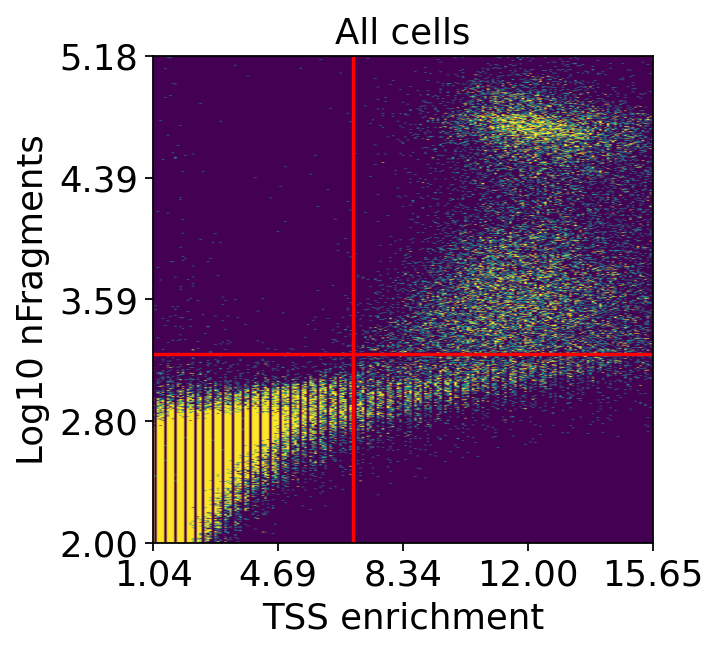

In [ ]:
x = np.log(atac_QC['nFrags'])/np.log(10)
y = atac_QC['TSSEnrichment']
h = np.histogram2d(x,y,bins=1000)
plt.imshow(h[0], vmax=2, aspect='auto')
plt.ylim([0,800])
plt.xlim([0,200])
plt.grid(False)
plt.plot([80,80], [0,800], color='red')
plt.plot([0,200], [310,310], color='red')
current_xticks = plt.gca().get_xticks()
plt.xticks(current_xticks, labels=['%.2f' % (x) for x in h[2][np.array([int(x) for x in np.floor(current_xticks)])]])
current_yticks = plt.gca().get_yticks()
plt.yticks(current_yticks, labels=['%.2f' % (x) for x in h[1][np.array([int(x) for x in np.floor(current_yticks)])]])
plt.xlabel("TSS enrichment")
plt.ylabel("Log10 nFragments")
plt.title("All cells")

nTSSFilter = h[2][80]
nFragFilter = h[1][310]

print("nFragFilter = %0.2f" % (nFragFilter))
print("TSSFilter = %0.2f" % (nTSSFilter))

In [ ]:
atac_QC['simplified_name'] = atac_names.copy()
atac_QC['custom_QC'] = np.logical_and(atac_QC['nFrags'] >= np.power(10, nFragFilter), atac_QC['TSSEnrichment'] >= nTSSFilter)
atac_QC['in_gex'] = np.array(ismember(atac_names, gex_names)[1])
atac_QC.to_csv(os.path.join(integrated_output, experiment_prefix + "_step0_atacQC_custom.csv"), index=None)


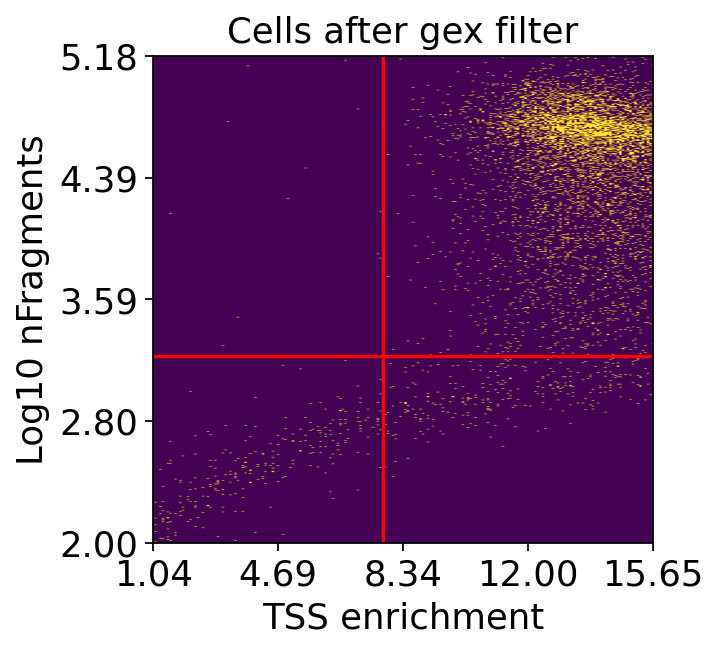

In [ ]:
cell_filter = atac_QC['in_gex']
x = np.log(atac_QC['nFrags'][cell_filter])/np.log(10)
y = atac_QC['TSSEnrichment'][cell_filter]
h2 = np.histogram2d(x,y,bins=1000)

plt.imshow(h2[0], vmax=1, aspect='auto')
plt.title("Cells after gex filter")
plt.ylim([0,800])
plt.xlim([0,200])
plt.grid(False)
current_xticks = plt.gca().get_xticks()
plt.xticks(current_xticks, labels=['%.2f' % (x) for x in h[2][np.array([int(x) for x in np.floor(current_xticks)])]])
current_yticks = plt.gca().get_yticks()
plt.yticks(current_yticks, labels=['%.2f' % (x) for x in h[1][np.array([int(x) for x in np.floor(current_yticks)])]])
plt.xlabel("TSS enrichment")
plt.ylabel("Log10 nFragments")
x_marker = np.max(np.where(h2[2] <= nTSSFilter)[0])
plt.plot([x_marker, x_marker], plt.gca().get_ylim(), color='red')
y_marker = np.max(np.where(h2[1] <= nFragFilter)[0])
plt.plot(plt.gca().get_xlim(), [y_marker, y_marker], color='red')


In [ ]:
np.sum(cell_filter)

np.int64(9713)

Import atac_QC matrix one last time to annotate doublets detected by ArchR

In [ ]:
atac_QC = pd.read_csv(os.path.join(integrated_output, experiment_prefix + "_step0_atacQC.csv"))


In [ ]:
adata.obs['archr_valid'] = pd.Categorical(ismember(gex_names, atac_names)[1])
## I decided not to exclude archr doublet calls because they don't form a distinct cluster
adata.obs['unclear'] = pd.Categorical(adata.obs['archr_valid'] == False)


In [ ]:
adata = adata[adata.obs['archr_valid'] == True,:].copy()

## Save final matrices

In [ ]:
del adata.obs['excluded']

In [ ]:
outputFile = os.path.join(integrated_output, experiment_prefix + "_step0_int_groupfilter_date20251110.h5ad")
sc.write(outputFile, adata = adata)

In [ ]:
adata_local = adata.copy()
adata_local.X = adata_local.layers['cellbender'].copy()
del adata_local.layers['cellbender']
del adata_local.layers['raw']
sc.write(filename = os.path.join(integrated_output, experiment_prefix + "_step0_LAYER_cellbender_groupfilter_date20251110.h5ad"), adata = adata_local)


In [ ]:
adata_local = adata.copy()
adata_local.X = adata_local.layers['raw'].copy()
del adata_local.layers['cellbender']
del adata_local.layers['raw']
sc.write(filename = os.path.join(integrated_output, experiment_prefix + "_step0_LAYER_raw_groupfilter_date20251110.h5ad"), adata = adata_local)
